In [ ]:
import surprise
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

from surprise import SVD, Dataset
from surprise.model_selection import cross_validate, train_test_split

# Load data

In [108]:
movies_dataset = surprise.Dataset.load_from_file("mvlenssmall/movielenssmall.csv",surprise.Reader())
movies_df = pd.DataFrame(movies_dataset.raw_ratings, columns=["uid", "iid", "rating", "jsp"])[["uid", "iid", "rating"]]
movies_df.uid = movies_df.uid.astype(int)
movies_df.iid = movies_df.iid.astype(int)
# X_train, X_test = train_test_split(movies_dataset)
titles = []
with open("mvlenssmall/titres.csv", "r") as f:
    for line in f:
        titles.append(line[re.match(r"\d", line).span()[1]+1:-1])
titles = np.array(titles, dtype = str)

# Preliminary analysis

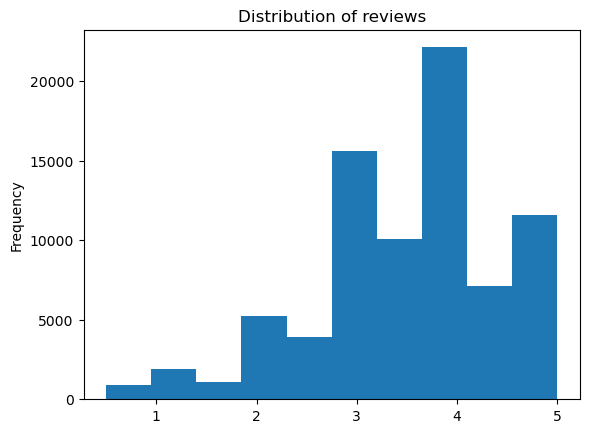

In [63]:
movies_df["rating"].plot.hist(bins=10)
plt.title("Distribution of reviews")
plt.show()

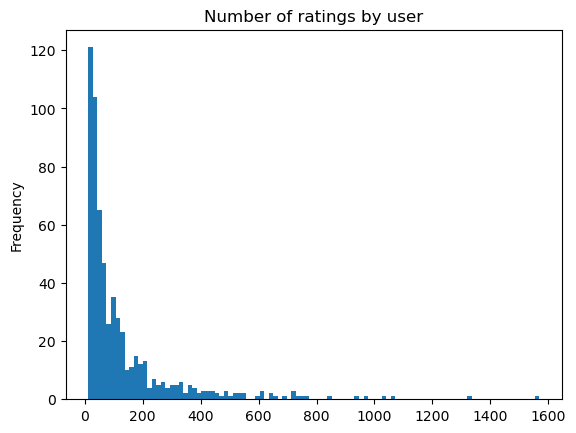

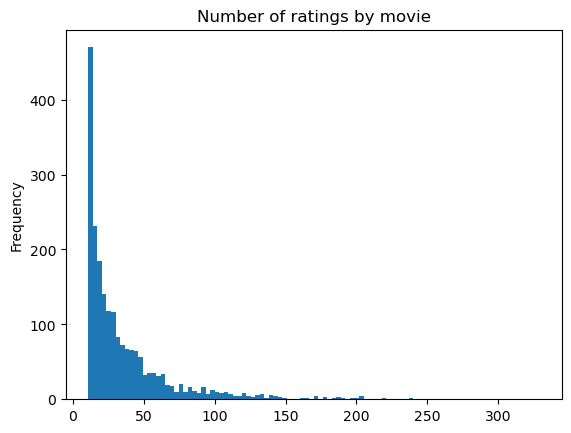

In [67]:
movies_df.groupby("uid")["rating"].count().plot.hist(bins=100)
plt.title("Number of ratings by user")
plt.show()

movies_df.groupby("iid")["rating"].count().plot.hist(bins=100)
plt.title("Number of ratings by movie")
plt.show()

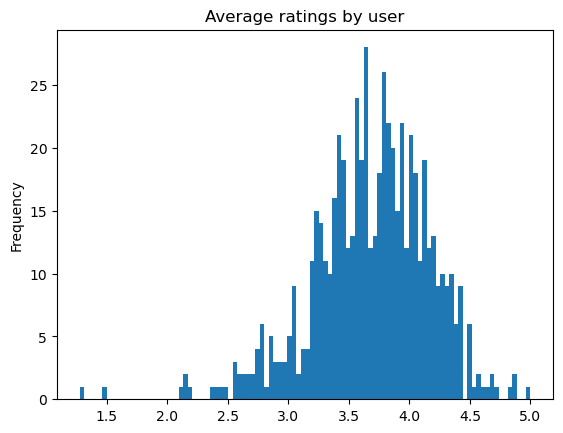

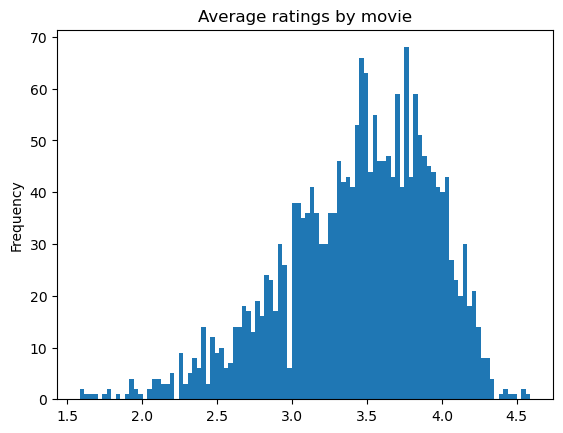

In [68]:
movies_df.groupby("uid")["rating"].mean().plot.hist(bins=100)
plt.title("Average ratings by user")
plt.show()

movies_df.groupby("iid")["rating"].mean().plot.hist(bins=100)
plt.title("Average ratings by movie")
plt.show()

In [106]:
best_movies_df = movies_df.groupby("iid")["rating"].mean().sort_values(ascending=False)[:50]
print(titles[list(best_movies_df.index)])

['1 Secrets & Lies (1996)' '28 Good Morning, Vietnam (1987)'
 '4 Enchanted April (1992)' '0 Rebel Without a Cause (1955)'
 '2 Waking Ned Devine (a.k.a. Waking Ned) (1998)'
 '1 Big Blue, The (Grand bleu, Le) (1988)'
 '1 Shawshank Redemption, The (1994)' '0 His Girl Friday (1940)'
 '2 Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)'
 '32 Lord of the Flies (1963)' '21 Death Wish 3 (1985)'
 '0 It Happened One Night (1934)' '4 Philadelphia Story, The (1940)'
 '36 Honey (2003)' ' Living in Oblivion (1995)' '3 Apocalypse Now (1979)'
 '9 12 Angry Men (1957)' '5 In the Name of the Father (1993)'
 '6 Hoop Dreams (1994)' "20 I'm Still Here (2010)"
 '0 Godfather, The (1972)' '6 Sting, The (1973)'
 "14 Assassin's Creed (2016)" '02 Home Alone 2: Lost in New York (1992)'
 '0 Highlander (1986)'
 '3 Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)'
 '5 Graduate, The (1967)' '9 Rear Window (1954)'
 '5 Blues Brothers, The (1980)'
 '34 Fear City: A Family-Style Comedy (La cité de 

In [129]:
n_users = movies_df.uid.unique().max()#.sort()
distance_matrix = np.zeros((n_users+1, n_users+1))

In [132]:
for i, (uid1, iid1, r1) in movies_df.iterrows():
    for j, (uid2, iid2, r2) in movies_df.iterrows():
        if iid1 == iid2:
            distance_matrix[int(uid1), int(uid2)] += (r1-r2)**2

KeyboardInterrupt: 

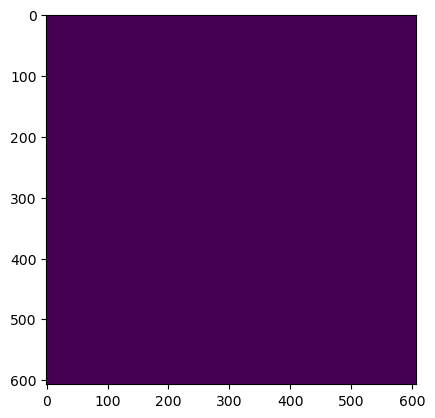

In [124]:
plt.imshow(distance_matrix)

In [ ]:
from surprise.similarities import cosine

: 

In [138]:
cosine(movies_dataset)

TypeError: cosine() takes exactly 3 positional arguments (1 given)